# **PySpark**

En este apartado, se va a realizar el preprocesamiento de los datos limpios obtenidos después del ***Análisis Exploratorio de los Datos***. Posterior a ello, se implementará el modelo **MLP (Multilayer Perceptron) de Clasificación** con **PYSPARK**.

## **Librerías**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.feature import VectorAssembler
import time
from pyspark.sql import SparkSession
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql import Row
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.ml.feature import StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [2]:
spark = SparkSession.builder \
    .appName("MLP") \
    .master("local[*]") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/08/23 15:06:38 WARN Utils: Your hostname, Valentina, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/08/23 15:06:38 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/23 15:06:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## **Base de datos**

In [3]:
data = spark.read.csv('../data/datalimpia.csv', header=True, inferSchema=True)
data.show(5)

25/08/23 15:06:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----------+----+-----+----------+--------------+----------+-------------------+------------------+----------+-----+-----------+--------------+-------------------+--------------------------+----------------+--------------+------------+------------------------+-----------+---------------------+--------------+--------+--------------------+---------------------+---------------------+---------------+---------+----------------+------------+------------------+------------------+--------------------+---------+---------------+--------------------------+-------------------+--------------------+-------+
|funded_amnt|term|grade|emp_length|home_ownership|annual_inc|verification_status|           purpose|addr_state|  dti|delinq_2yrs|inq_last_6mths|initial_list_status|collections_12_mths_ex_med|application_type|acc_now_delinq|tot_coll_amt|chargeoff_within_12_mths|delinq_amnt|mo_sin_rcnt_rev_tl_op|mo_sin_rcnt_tl|mort_acc|mths_since_recent_bc|mths_since_recent_inq|num_accts_ever_120_pd|num_actv_rev_t

## **Preprocesamiento**

En esta sección, al igual que en la de ***Scikit*** que tiene el mismo nombre, se aplicaron distintas técnicas relacionadas con el correcto manejo de los datos con el fin de dejar la base a utilizar lo más limpia y ordenada posible para que el modelo pueda ser lo más eficiente posible. 

In [22]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder

# Clasificación de columnas según su naturaleza
ord_cols = ["grade"]
nom_cols = [f.name for f in data.schema.fields if isinstance(f.dataType, StringType) and f.name not in ord_cols]
numerical_cols = [f.name for f in data.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType)) and f.name != "default"]

# Codificación y escalado
indexers_nom = [StringIndexer(inputCol=col, outputCol=f"{col}_index") for col in nom_cols]
encoders_nom = [OneHotEncoder(inputCol=f"{col}_index", outputCol=f"{col}_encoded") for col in nom_cols]

indexers_ord = [StringIndexer(inputCol=col, outputCol=f"{col}_index") for col in ord_cols]

assembler_num = VectorAssembler(inputCols=numerical_cols, outputCol="num_features")
scaler = StandardScaler(inputCol="num_features", outputCol="scaled_features")

categorical_encoded = [f"{col}_encoded" for col in nom_cols] + [f"{col}_index" for col in ord_cols]
assembler_all = VectorAssembler(
    inputCols=["scaled_features"] + categorical_encoded,
    outputCol="features"
)

# Pipeline completo
pipeline = Pipeline(stages=indexers_nom + encoders_nom + indexers_ord + [assembler_num, scaler, assembler_all])

# Ajustar pipeline al dataset completo
pipeline_model = pipeline.fit(data)
dataspark = pipeline_model.transform(data)

print("Dataset después del pipeline:")
dataspark.select("features", "default").show(5, truncate=False)

Dataset después del pipeline:
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------+
|features                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |default|
+---------------------------

In [23]:
label_col = "default"
df_features = dataspark.select("features", "default")

# Clases únicas
classes = df_features.select(label_col).distinct().rdd.flatMap(lambda x: x).collect()

# División estratificada 80-20
fractions = {c: 0.8 for c in classes}

train_df = df_features.sampleBy(label_col, fractions, seed=21)
test_df = df_features.subtract(train_df)

print("El conjunto de entrenamiento cuenta con", train_df.count(), "observaciones y el de prueba con", test_df.count())

El conjunto de entrenamiento cuenta con 1075894 observaciones y el de prueba con 269416


Es evidente el desbalanceo del que se viene hablando durante todo el proyecto.

In [25]:
from pyspark.sql.functions import col

# Cantidad de registros hay en cada clase
cantclase = train_df.groupBy(label_col).count().collect()

clasemayor = max(cantclase, key=lambda x: x["count"])[label_col]
clasemenor = min(cantclase, key=lambda x: x["count"])[label_col]
mayor_count = max(cantclase, key=lambda x: x["count"])["count"]
menor_count = min(cantclase, key=lambda x: x["count"])["count"]

print("Antes del balanceo:")
train_df.groupBy(label_col).count().orderBy(label_col).show()

# Separar las clases
datadefault = train_df.filter(col(label_col) == clasemayor)
datacharged = train_df.filter(col(label_col) == clasemenor)

datadefault_reduced = datadefault.sample(withReplacement=False, fraction=0.5, seed=21)

target_count = mayor_count // 2  
oversample_fraction = target_count / menor_count

datacharged_oversampled = datacharged.sample(withReplacement=True, fraction=oversample_fraction, seed=21)

datatrainbal = datadefault_reduced.union(datacharged_oversampled)
print("Después del balanceo:")
datatrainbal.groupBy(label_col).count().show()

Antes del balanceo:


+-------+------+
|default| count|
+-------+------+
|      0|861213|
|      1|214681|
+-------+------+

Después del balanceo:


+-------+------+
|default| count|
+-------+------+
|      0|430345|
|      1|431207|
+-------+------+



Para la realización de este ejercicio se optó por combinar técnicas de subsampling y oversampling. Esta decisión se tomó debido a limitaciones de memoria RAM, ya que al aplicar únicamente oversampling la cantidad de datos resultante no era manejable. Con la estrategia combinada, se obtuvo una base balanceada y con un volumen de datos representativo para el análisis.

## **Modelo MLP**

In [9]:
num_features = len(datatrainbal.select("features").first()["features"])
print(f"Número de features: {num_features}")

Número de features: 103


In [10]:
layers_list = [
    [num_features, 10, 2],
    [num_features, 50, 2],
    [num_features, 100, 2]
]
step_sizes = [0.1, 0.01, 0.001]
max_iters = [100]

In [12]:
binary_eval = BinaryClassificationEvaluator(labelCol="default", rawPredictionCol="prediction", metricName="areaUnderROC")
accuracy_eval = MulticlassClassificationEvaluator(labelCol="default", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="default", predictionCol="prediction", metricName="f1")
recall_eval = MulticlassClassificationEvaluator(labelCol="default", predictionCol="prediction", metricName="weightedRecall")

results = []
best_model_data = None  

for layers in layers_list:
    for step in step_sizes:
        for iters in max_iters:

            mlp = MultilayerPerceptronClassifier(
                featuresCol="features",
                labelCol="default",
                layers=layers,
                blockSize=128,
                seed=21,
                maxIter=iters,
                stepSize=step
            )

            start_time = time.time()
            model = mlp.fit(datatrainbal)
            train_time = time.time() - start_time

            start_time = time.time()
            predictions = model.transform(test_df)
            pred_time = time.time() - start_time
            
            auc_val = binary_eval.evaluate(predictions)
            accuracy = accuracy_eval.evaluate(predictions)
            f1 = f1_eval.evaluate(predictions)
            recall = recall_eval.evaluate(predictions)

            if best_model_data is None or recall > best_model_data["recall"]:
                pdf = predictions.select("default", "prediction", "probability").toPandas()
                y_true = pdf["default"].values
                y_pred = pdf["prediction"].values
                y_prob = pdf["probability"].apply(lambda x: x[1]).values

                best_model_data = {
                    "layers": layers,
                    "stepSize": step,
                    "maxIter": iters,
                    "train_time": train_time,
                    "pred_time": pred_time,
                    "auc": auc_val,
                    "accuracy": accuracy,
                    "f1": f1,
                    "recall": recall,
                    "y_true": y_true,
                    "y_pred": y_pred,
                    "y_prob": y_prob,
                    "model": model
                }

25/08/23 15:07:41 WARN MemoryStore: Not enough space to cache rdd_217_7 in memory! (computed 18.2 MiB so far)
25/08/23 15:07:41 WARN BlockManager: Persisting block rdd_217_7 to disk instead.
25/08/23 15:07:42 WARN MemoryStore: Not enough space to cache rdd_217_5 in memory! (computed 28.0 MiB so far)
25/08/23 15:07:42 WARN BlockManager: Persisting block rdd_217_5 to disk instead.
25/08/23 15:07:43 WARN MemoryStore: Not enough space to cache rdd_217_4 in memory! (computed 43.0 MiB so far)
25/08/23 15:07:43 WARN BlockManager: Persisting block rdd_217_4 to disk instead.
25/08/23 15:07:46 WARN MemoryStore: Not enough space to cache rdd_217_7 in memory! (computed 6.7 MiB so far)
25/08/23 15:07:46 WARN MemoryStore: Not enough space to cache rdd_217_4 in memory! (computed 6.7 MiB so far)
25/08/23 15:07:47 WARN MemoryStore: Not enough space to cache rdd_217_5 in memory! (computed 28.0 MiB so far)
25/08/23 15:07:47 WARN MemoryStore: Not enough space to cache rdd_217_4 in memory! (computed 18.2 M

In [ ]:
import pandas as pd
best_table = pd.DataFrame([{
    "layers": best_model_data["layers"],
    "stepSize": best_model_data["stepSize"],
    "maxIter": best_model_data["maxIter"],
    "Tiempo de entrenamiento": best_model_data["train_time"],
    "Tiempo de test": best_model_data["pred_time"],
    "ROC AUC": best_model_data["auc"],
    "Accuracy": best_model_data["accuracy"],
    "F1-Score": best_model_data["f1"],
    "Recall": best_model_data["recall"]
}])

In [21]:
print(f"Los mejores hiperparámetros fueron: "
      f"layers = {best_model_data['layers']}, "
      f"stepSize = {best_model_data['stepSize']}, "
      f"maxIter = {best_model_data['maxIter']}")

Los mejores hiperparámetros fueron: layers = [103, 100, 2], stepSize = 0.1, maxIter = 100


In [20]:
print(f"Tiempo de entrenamiento: {best_model_data['train_time']:.2f} ")
print(f"Tiempo de predicción: {best_model_data['pred_time']:.2f}")

Tiempo de entrenamiento: 5286.55 
Tiempo de predicción: 0.04


## **Métricas y valores resultantes**

In [19]:
metricas = pd.DataFrame([{
    "Accuracy": best_model_data["accuracy"],
    "Recall": best_model_data["recall"],
    "F1-Score": best_model_data["f1"],
    "ROC AUC": best_model_data["auc"]
}])
print(metricas)

   Accuracy    Recall  F1-Score   ROC AUC
0  0.708495  0.708495  0.732069  0.673301


A partir de los resultados obtenidos, podemos observar que el modelo presenta un desempeño considerable en términos generales. 

La métrica `Recall` indica que **se logra identificar correctamente alrededor del 70% de los casos reales de morosidad**, lo cual es un valor positivo dentro de este contexto.

Por otro lado, el valor de `ROC AUC = 0.67` muestra que el modelo tiene una capacidad de discriminación moderada, es decir, logra distinguir a los morosos de los no morosos mejor que un modelo aleatorio.

## **Matriz de confusión**

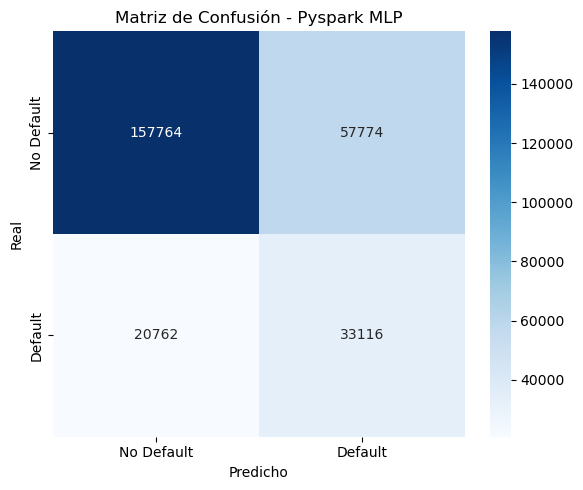

In [14]:
cm = confusion_matrix(best_model_data["y_true"], best_model_data["y_pred"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"])
plt.title("Matriz de Confusión - Pyspark MLP")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("confusion_matrix_pyspark.png")
plt.show()
plt.close()

Los resultados de la matriz de confusión se alinean con lo observado previamente en las métricas de evaluación. Entre las predicciones correctas, el modelo identificó **157764** casos pertenecientes a la clase 0 (no morosos) y **33116** correspondientes a la clase 1 (morosos). No obstante, se observa que **20762** casos de la clase positiva no fueron reconocidos adecuadamente, lo que implica un número importante de falsos negativos. Asimismo, se evidencia que **57774** casos de la clase negativa fueron clasificados erróneamente como positivos, lo que representa un volumen considerable de falsos positivos.

## **Curva ROC**

/tmp/ipykernel_894/883888296.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


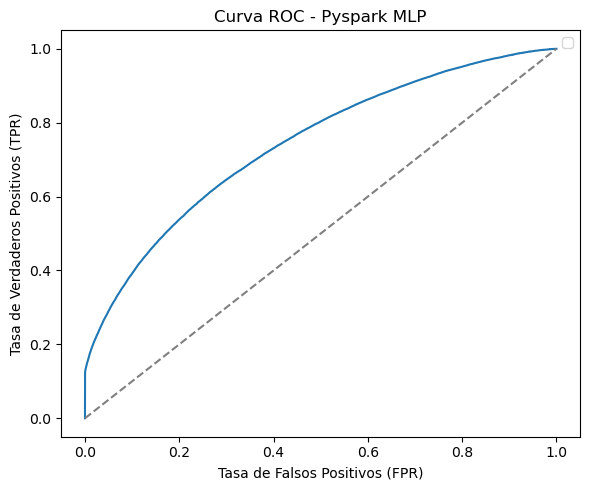

In [27]:
fpr, tpr, _ = roc_curve(best_model_data["y_true"], best_model_data["y_prob"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Pyspark MLP")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_pyspark.png")
plt.show()
plt.close()

Como se esperaba, la curva ROC se encuentra por encima de la diagonal, lo cual indica que el modelo tiene capacidad de distinción. Con un AUC de `0.67`, se puede reafirmar que el rendimiento del modelo es significativamente mejor que el de una predicción aleatoria.

In [ ]:
best_result_without_model = {k: v for k, v in best_model_data.items() if k != "model"}

output_data = {
    "best_result": best_result_without_model,
    "best_table": best_table,
    "confusion_matrix": cm,
    "roc_auc": roc_auc,
    "confusion_matrix_img": "confusion_matrix_pyspark.png",
    "roc_curve_img": "roc_curve_pyspark.png"
}

with open("best_model_results.pkl", "wb") as f:
    pickle.dump(output_data, f)

print("\n✅ Todo guardado en 'best_model_results.pkl'")
best_model_data["model"].write().overwrite().save("best_spark_model")


✅ Todo guardado en 'best_model_results.pkl'
